In [1]:
import pandas as pd

In [2]:
from google.colab import files

files.upload()

Saving churn-bigml-80.csv to churn-bigml-80.csv
Saving churn-bigml-20.csv to churn-bigml-20.csv


{'churn-bigml-80.csv': b'State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn\nKS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.7,1,False\nOH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False\nNJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False\nOH,84,408,Yes,No,0,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False\nOK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False\nAL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.7,0,False\nMA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False\nMO,147,415,Yes,No,0,157.0,79,26.69,103.1,94

In [3]:
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

In [4]:
for df in [train_df, test_df]:
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)

train_df = pd.get_dummies(train_df, columns=['State'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['State'], drop_first=True)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


In [7]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # input layer, sesuai jumlah fitur
    layers.Dense(32, activation='relu'),               # hidden layer 1
    layers.Dense(16, activation='relu'),                # hidden layer 2
    layers.Dense(1, activation='sigmoid')                # output layer (binary classification)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')]
)

In [9]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,  # 20% dari data train dipakai untuk validasi selama training
    verbose=1
)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6862 - loss: 0.5906 - recall: 0.2746 - val_accuracy: 0.8258 - val_loss: 0.4812 - val_recall: 0.0215
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8612 - loss: 0.3862 - recall: 0.0169 - val_accuracy: 0.8277 - val_loss: 0.4490 - val_recall: 0.0108
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8626 - loss: 0.3530 - recall: 0.0136 - val_accuracy: 0.8277 - val_loss: 0.4230 - val_recall: 0.0215
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8659 - loss: 0.3300 - recall: 0.0441 - val_accuracy: 0.8258 - val_loss: 0.4114 - val_recall: 0.0215
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8715 - loss: 0.3150 - recall: 0.0949 - val_accuracy: 0.8277 - val_loss: 0.3997 - val_recall: 0.0538
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8776 - loss: 0.3004 - recall: 0.1593 - val_accuracy: 0.8277 - val_loss: 0.3914 - val_recall: 0.1183
Epoch 7/50
67/6

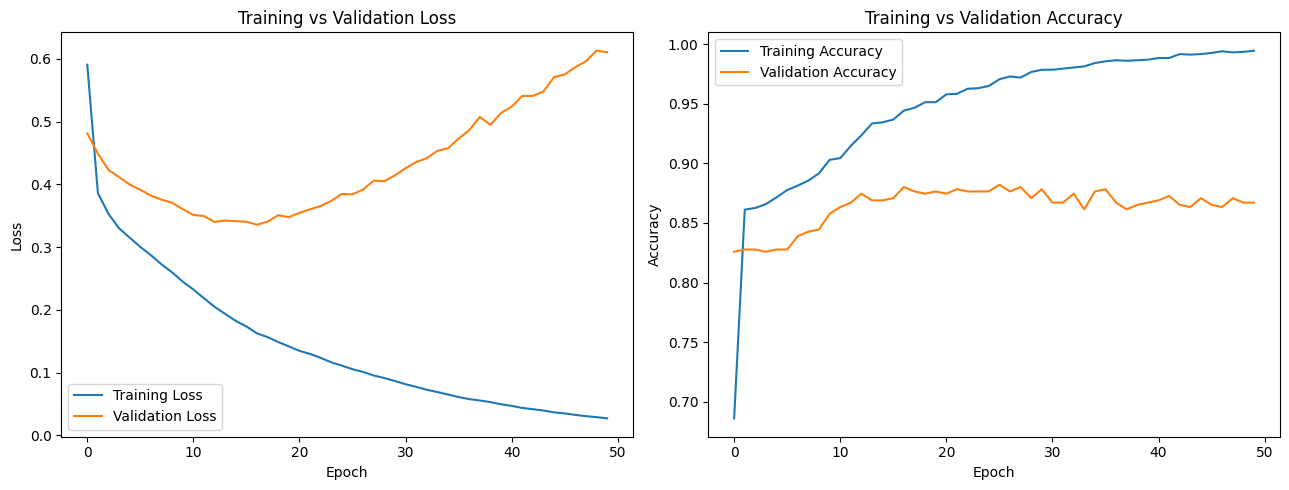

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_proba = model.predict(X_test_scaled)
y_pred_nn = (y_pred_proba > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Confusion Matrix:
[[539  33]
 [ 46  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       572
           1       0.60      0.52      0.55        95

    accuracy                           0.88       667
   macro avg       0.76      0.73      0.74       667
weighted avg       0.88      0.88      0.88       667



In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Buat ulang model (reset bobot)
model2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),                    # tambahan: dropout untuk regularisasi
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,             # berhenti kalau val_loss tidak membaik 5 epoch berturut-turut
    restore_best_weights=True  # otomatis kembali ke bobot terbaik
)

history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7706 - loss: 0.5279 - recall: 0.1220 - val_accuracy: 0.8258 - val_loss: 0.4777 - val_recall: 0.0000e+00
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8462 - loss: 0.4430 - recall: 0.0339 - val_accuracy: 0.8258 - val_loss: 0.4597 - val_recall: 0.0000e+00
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8565 - loss: 0.4242 - recall: 0.0373 - val_accuracy: 0.8258 - val_loss: 0.4451 - val_recall: 0.0000e+00
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8640 - loss: 0.4017 - recall: 0.0407 - val_accuracy: 0.8277 - val_loss: 0.4340 - val_recall: 0.0108
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8588 - loss: 0.3964 - recall: 0.0271 - val_accuracy: 0.8296 - val_loss: 0.4242 - val_recall: 0.0215
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8602 - loss: 0.3736 - recall: 0.0441 - val_accuracy: 0.8296 - val_loss: 0.4170 - val_recall: 0.0215
Epoc

In [13]:
y_pred_proba2 = model2.predict(X_test_scaled)
y_pred_nn2 = (y_pred_proba2 > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn2))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       572
           1       0.71      0.43      0.54        95

    accuracy                           0.89       667
   macro avg       0.81      0.70      0.74       667
weighted avg       0.88      0.89      0.88       667



## Conclusion

A feed-forward neural network was built using TensorFlow/Keras to predict customer churn, using the same 69 features as the earlier Logistic Regression and Random Forest tasks.

The initial model (2 hidden layers, 50 epochs, no regularization) showed clear overfitting: training accuracy reached 99.4% while validation accuracy plateaued around 87%, and test recall for the churn class was only 52% despite 96.6% recall on training data. The training vs. validation loss plot confirmed this — validation loss reached its minimum around epoch 12-15, then increased steadily while training loss kept falling.

To address this, a second model was built with **Dropout layers (0.3)** and **EarlyStopping** (monitoring validation loss, patience=5). Training stopped automatically at epoch 33, restoring the best weights. This improved precision for the churn class (60% → 71%) but slightly reduced recall (52% → 43%), reflecting a shift toward more conservative predictions.

**Comparing all three models built on this dataset:**

| Model | Accuracy | Recall (Churn) | Precision (Churn) |
|---|---|---|---|
| Logistic Regression | 85.9% | 25% | 51% |
| Random Forest | 95.1% | 66% | 98% |
| Neural Network (regularized) | 89% | 43% | 71% |

Interestingly, **Random Forest outperformed the Neural Network** on this dataset. This is a common finding for small-to-medium sized tabular data: tree-based ensemble methods often outperform neural networks, which typically need much larger datasets to fully leverage their capacity. Neural networks tend to shine more on unstructured data (images, text, audio) rather than structured tabular